# Probabilistic Autoregressive Forecasting: A Practical Guide

**Companion notebook to:** *"Your Model's MSE Is Lying to You Part II: Autoregressive Rollout and Uncertainty Propagation"*

In the [previous notebook](https://github.com/wesmail/probabilistic-forecasting/tree/main/01-point-vs-probabilistic), we trained a probabilistic model that predicts $\mu$ and $\sigma$ **one step ahead**. That's useful, but in practice you need a forecast over the next 10, 50, or 100 steps.

This notebook answers a single question: **how do you roll a probabilistic model forward over many steps, and keep the uncertainty honest?**

We'll see that the naive approach (feeding $\mu$ back as if it were the true value) systematically underestimates uncertainty, and that the correct approach (sampling and feeding the sample back, many times) is barely more code but gives fundamentally better forecasts.

Runtime: a few minutes on CPU. No GPU needed.

## 1. Quick recap: the model from Part 1

We reuse the **exact same setup** from the first notebook: a synthetic signal with heteroscedastic noise, a small transformer backbone, and Gaussian NLL training. This section is a condensed repeat see the [Part 1 notebook](https://github.com/wesmail/probabilistic-forecasting/tree/main/01-point-vs-probabilistic) for the full explanation.

The signal:
$$x(t) = A_1 \sin(2\pi t / P_1) + A_2 \sin(2\pi t / P_2 + \phi) + \varepsilon(t), \qquad \varepsilon(t) \sim \mathcal{N}(0,\, \sigma(t)^2)$$

The noise standard deviation $\sigma(t)$ oscillates on its own period — quiet stretches and noisy stretches, just like real physical data.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import norm

torch.manual_seed(0)
np_rng = np.random.default_rng(0)

# ── Generate the same signal as Part 1 ──────────────────────

def generate_series(n_steps=3000, dt=1.0,
                    A1=1.0, P1=200.0, A2=0.4, P2=37.0,
                    sigma_min=0.05, sigma_max=0.45, P_noise=130.0, seed=0):
    rng = np.random.default_rng(seed)
    t = np.arange(n_steps) * dt
    signal = A1 * np.sin(2 * np.pi * t / P1) + A2 * np.sin(2 * np.pi * t / P2 + 0.7)
    sigma_t = sigma_min + (sigma_max - sigma_min) * 0.5 * (1 + np.sin(2 * np.pi * t / P_noise - np.pi/2))
    x = signal + rng.normal(0.0, sigma_t)
    return t, x, signal, sigma_t

t, x, signal, sigma_t = generate_series()

# ── Slice into (context, target) windows ────────────────────

CONTEXT = 20   # T: how many past steps the model sees

def make_windows(series, ctx_len):
    X, y = [], []
    for i in range(len(series) - ctx_len):
        X.append(series[i : i + ctx_len])
        y.append(series[i + ctx_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = make_windows(x, CONTEXT)
n_train = int(0.7 * len(X))
X_train_t = torch.from_numpy(X[:n_train])
y_train_t = torch.from_numpy(y[:n_train])

print(f"signal: {len(x)} steps  |  train windows: {n_train}  |  test steps available: {len(x) - n_train - CONTEXT}")

signal: 3000 steps  |  train windows: 2086  |  test steps available: 894


In [2]:
# ── Model: identical to Part 1 ──────────────────────────────

class ForecastTransformer(nn.Module):
    def __init__(self, context_len, d_model=32, nhead=4, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_embed  = nn.Parameter(torch.zeros(1, context_len, d_model))
        nn.init.normal_(self.pos_embed, std=0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            batch_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head    = nn.Linear(d_model, 2)   # outputs (mu, log_sigma)

    def forward(self, x):
        h = self.input_proj(x.unsqueeze(-1)) + self.pos_embed
        h = self.encoder(h)
        out = self.head(h[:, -1, :])           # summarise at last position
        mu, log_sigma = out[:, 0], out[:, 1]
        log_sigma = torch.clamp(log_sigma, min=-5.0, max=2.0)
        return mu, log_sigma


def gaussian_nll(mu, log_sigma, target):
    sigma = torch.exp(log_sigma)
    return (log_sigma + 0.5 * ((target - mu) / sigma) ** 2).mean()


# ── Train ───────────────────────────────────────────────────

def train(model, epochs=150, lr=1e-3, batch_size=64):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = X_train_t.shape[0]
    for epoch in range(epochs):
        perm = torch.randperm(n)
        total = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i : i + batch_size]
            xb, yb = X_train_t[idx], y_train_t[idx]
            opt.zero_grad()
            mu, log_sigma = model(xb)
            loss = gaussian_nll(mu, log_sigma, yb)
            loss.backward()
            opt.step()
            total += loss.item() * len(idx)
        if (epoch + 1) % 50 == 0:
            print(f"  epoch {epoch+1:3d}   loss {total/n:.4f}")

model = ForecastTransformer(CONTEXT)
print("Training probabilistic model...")
train(model)
model.eval()
print("Done.")

Training probabilistic model...
  epoch  50   loss -0.7968
  epoch 100   loss -0.8703
  epoch 150   loss -0.9320
Done.


## 2. The multi-step problem

Our model can predict one step ahead: given $x_1, \ldots, x_T$, it outputs $(\mu_{T+1}, \sigma_{T+1})$. That works.

But in practice, you want to know what happens over the next $H$ steps. To predict step $T+2$, the model needs step $T+1$ as input — which we don't have. We only have a *prediction* for it, and that prediction is uncertain.

How we handle this "uncertain input" is the whole story. There are two options, and they give very different results. See the companion post for the full mathematical argument — here we'll see the difference in code and plots.

## 3. Deterministic rollout (Option A): feed $\mu$ back

The simplest approach: at each step, predict $(\mu, \sigma)$, then plug $\mu$ into the context as if it were the true observed value.

**The problem:** the $\sigma$ values are computed as if the previous steps were known exactly. They capture only the local noise at each step, ignoring the uncertainty inherited from all previous predictions. This **underestimates** total forecast uncertainty, especially at long horizons.

In [3]:
HORIZON = 50   # predict 50 steps into the future

@torch.no_grad()
def deterministic_rollout(model, context, horizon):
    """Roll forward by feeding mu back at each step.
    Returns arrays of shape (horizon,) for both mu and sigma."""
    ctx = context.clone()                    # shape: (T,)
    mus, sigmas = [], []

    for h in range(horizon):
        mu, log_sigma = model(ctx.unsqueeze(0))          # (1,) each
        sigma = torch.exp(log_sigma)
        mus.append(mu.item())
        sigmas.append(sigma.item())
        ctx = torch.cat([ctx[1:], mu.reshape(1)])        # slide window: drop oldest, append mu

    return np.array(mus), np.array(sigmas)

Let's pick a test window and run the deterministic rollout. We'll choose a starting point in the test region where the signal passes through both quiet and noisy stretches.

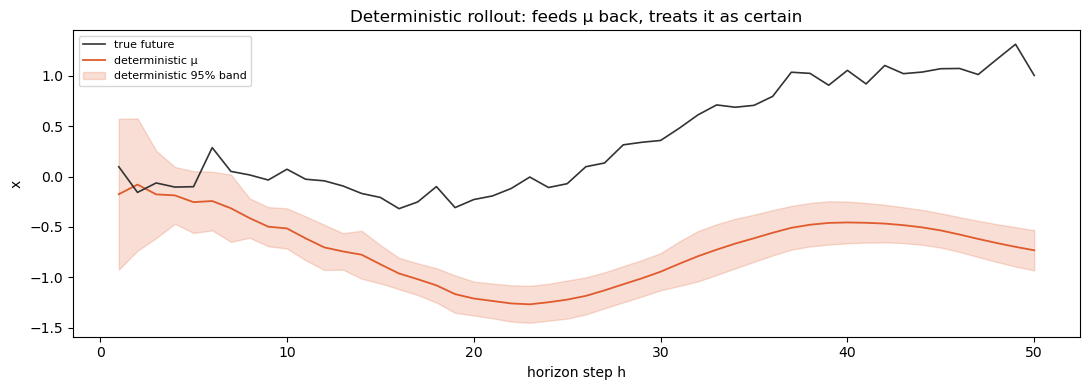

In [4]:
# Pick a starting point in the test region
start = n_train + CONTEXT + 60   # well into the test set
context = torch.from_numpy(x[start : start + CONTEXT].astype(np.float32))
true_future = x[start + CONTEXT : start + CONTEXT + HORIZON]
true_sigma  = sigma_t[start + CONTEXT : start + CONTEXT + HORIZON]

# Run deterministic rollout
mu_det, sigma_det = deterministic_rollout(model, context, HORIZON)

# Plot
h_axis = np.arange(1, HORIZON + 1)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(h_axis, true_future, color="#333", lw=1.2, label="true future", zorder=3)
ax.plot(h_axis, mu_det, color="#e05a2b", lw=1.3, label="deterministic μ")
ax.fill_between(h_axis, mu_det - 1.96*sigma_det, mu_det + 1.96*sigma_det,
                color="#e05a2b", alpha=0.2, label="deterministic 95% band")
ax.set_xlabel("horizon step h")
ax.set_ylabel("x")
ax.legend(fontsize=8)
ax.set_title("Deterministic rollout: feeds μ back, treats it as certain")
plt.tight_layout()
plt.show()

The band looks reasonable at first glance. But notice: its width barely grows over the horizon. That's suspicious — the further out you predict, the less you know, so honest uncertainty should *widen* over time.

## 4. Stochastic rollout (Option B): sample and feed back

The correct approach: at each step, **draw a random sample** from $(\mu, \sigma)$ and feed that back. Run this $M$ times to get $M$ plausible futures.

Each trajectory starts from the same real history but diverges because of the random draws. The randomness at step 1 changes the context at step 2, which changes the prediction, which changes the sample, all the way through. **Uncertainty propagates automatically.**

In [5]:
@torch.no_grad()
def stochastic_rollout(model, context, horizon, M=500):
    """Run M independent stochastic trajectories.
    Returns a numpy array of shape (M, horizon)."""
    # Copy the context M times → batch of shape (M, T)
    ctx = context.unsqueeze(0).expand(M, -1).clone()
    trajectories = torch.zeros(M, horizon)

    for h in range(horizon):
        mu, log_sigma = model(ctx)                       # (M,) each
        sigma = torch.exp(log_sigma)

        # Each trajectory draws its own random sample
        sample = mu + sigma * torch.randn(M)
        trajectories[:, h] = sample

        # Slide each trajectory's window: drop oldest, append its sample
        ctx = torch.cat([ctx[:, 1:], sample.unsqueeze(1)], dim=1)

    return trajectories.numpy()

In [6]:
# Run M=500 stochastic trajectories from the same starting context
M = 500
trajs = stochastic_rollout(model, context, HORIZON, M=M)

# Compute summary statistics across the M dimension
median_traj = np.median(trajs, axis=0)
q05 = np.percentile(trajs, 5, axis=0)     # 5th percentile
q95 = np.percentile(trajs, 95, axis=0)     # 95th percentile
q25 = np.percentile(trajs, 25, axis=0)     # 25th percentile
q75 = np.percentile(trajs, 75, axis=0)     # 75th percentile

Now let's plot the trajectories. Each light line is one plausible future. The shaded bands are the 50% and 90% envelopes computed from the ensemble.

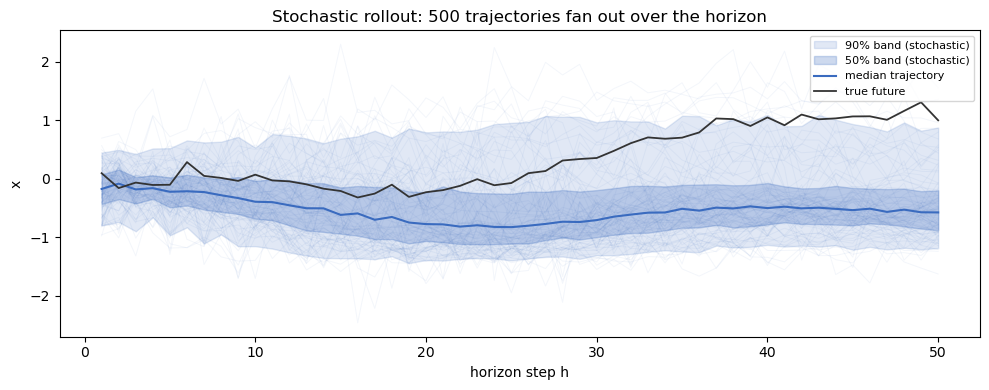

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

# Draw a subset of individual trajectories (spaghetti)
n_show = 80
for m in range(n_show):
    ax.plot(h_axis, trajs[m], color="#3a6bbf", alpha=0.06, lw=0.7)

# Quantile bands
ax.fill_between(h_axis, q05, q95, color="#3a6bbf", alpha=0.15, label="90% band (stochastic)")
ax.fill_between(h_axis, q25, q75, color="#3a6bbf", alpha=0.25, label="50% band (stochastic)")
ax.plot(h_axis, median_traj, color="#3a6bbf", lw=1.5, label="median trajectory")
ax.plot(h_axis, true_future, color="#333", lw=1.3, label="true future", zorder=3)

ax.set_xlabel("horizon step h")
ax.set_ylabel("x")
ax.legend(fontsize=8, loc="upper right")
ax.set_title(f"Stochastic rollout: {M} trajectories fan out over the horizon")
plt.tight_layout()
plt.show()

Notice the fan: trajectories start close together (they share the same real context) and spread apart over time. The band naturally widens as uncertainty accumulates — nobody told it to do that, it happens because each step's randomness compounds.

## 5. Side-by-side: deterministic vs. stochastic bands

Now the real comparison. Same starting context, same horizon. One plot.

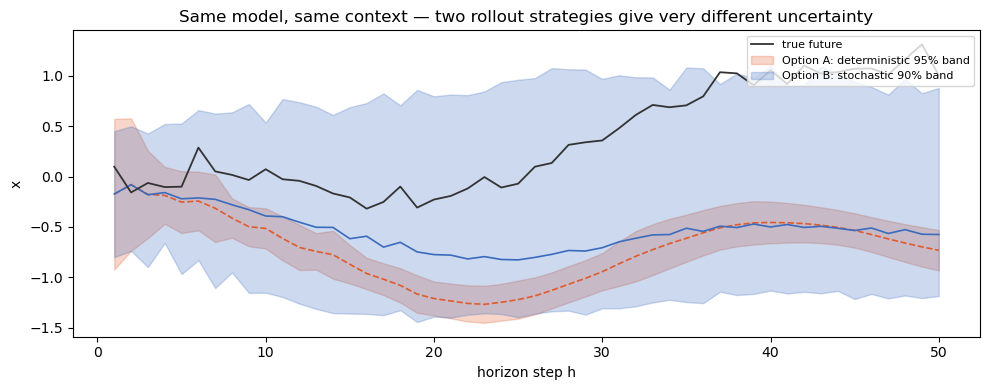

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

# True future
ax.plot(h_axis, true_future, color="#333", lw=1.3, label="true future", zorder=4)

# Deterministic rollout band (Option A)
ax.fill_between(h_axis, mu_det - 1.96*sigma_det, mu_det + 1.96*sigma_det,
                color="#e05a2b", alpha=0.25, label="Option A: deterministic 95% band")
ax.plot(h_axis, mu_det, color="#e05a2b", lw=1.2, ls="--")

# Stochastic rollout band (Option B)
ax.fill_between(h_axis, q05, q95, color="#3a6bbf", alpha=0.25, label="Option B: stochastic 90% band")
ax.plot(h_axis, median_traj, color="#3a6bbf", lw=1.2)

ax.set_xlabel("horizon step h")
ax.set_ylabel("x")
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Same model, same context — two rollout strategies give very different uncertainty")
plt.tight_layout()
plt.show()

The orange band (deterministic) stays roughly constant in width — it only sees the local noise at each step. The blue band (stochastic) widens naturally because it accounts for the **inherited uncertainty** from every previous step. See the post for the mathematical proof (law of total variance).

## 6. The test: coverage across the horizon

One example is anecdotal. Let's run both rollout strategies from **many** starting points in the test set and check: at each horizon step $h$, does the 90% band actually contain the true value about 90% of the time?

If the band is honest, coverage $\approx$ 90% at every $h$. If it underestimates uncertainty, coverage drops as $h$ grows.

In [9]:
# Evaluate over many test windows
test_start = n_train + CONTEXT           # first valid test position
test_end   = len(x) - CONTEXT - HORIZON  # last valid start position
eval_starts = np.arange(test_start, test_end, 5)   # every 5th step to save compute
N_eval = len(eval_starts)
M_eval = 200   # trajectories per window (enough for 90% quantiles)

print(f"Evaluating {N_eval} test windows, {M_eval} trajectories each...")

# Storage: (N_eval, HORIZON) — whether the truth was inside the band at each (window, horizon)
in_band_det = np.zeros((N_eval, HORIZON), dtype=bool)
in_band_sto = np.zeros((N_eval, HORIZON), dtype=bool)

for idx, s in enumerate(eval_starts):
    ctx = torch.from_numpy(x[s : s + CONTEXT].astype(np.float32))
    truth = x[s + CONTEXT : s + CONTEXT + HORIZON]

    # Option A: deterministic
    mu_d, sig_d = deterministic_rollout(model, ctx, HORIZON)
    lo_d, hi_d  = mu_d - 1.645 * sig_d, mu_d + 1.645 * sig_d    # 90% Gaussian interval
    in_band_det[idx] = (truth >= lo_d) & (truth <= hi_d)

    # Option B: stochastic
    tr = stochastic_rollout(model, ctx, HORIZON, M=M_eval)
    lo_s = np.percentile(tr, 5, axis=0)
    hi_s = np.percentile(tr, 95, axis=0)
    in_band_sto[idx] = (truth >= lo_s) & (truth <= hi_s)

    if (idx + 1) % 40 == 0:
        print(f"  {idx+1}/{N_eval} done")

print("Done.")

Evaluating 165 test windows, 200 trajectories each...
  40/165 done
  80/165 done
  120/165 done
  160/165 done
Done.


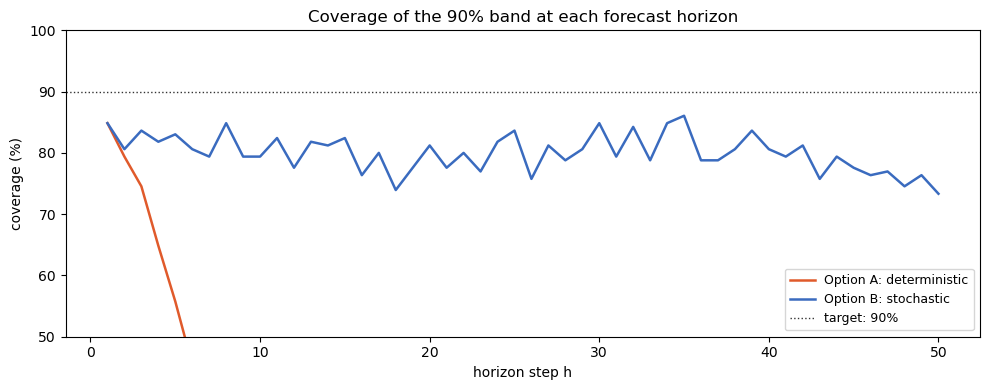

In [10]:
# Coverage at each horizon step: fraction of test windows where truth was inside the band
coverage_det = in_band_det.mean(axis=0)   # shape: (HORIZON,)
coverage_sto = in_band_sto.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(h_axis, coverage_det * 100, color="#e05a2b", lw=1.8, label="Option A: deterministic")
ax.plot(h_axis, coverage_sto * 100, color="#3a6bbf", lw=1.8, label="Option B: stochastic")
ax.axhline(90, color="#333", ls=":", lw=1, label="target: 90%")
ax.set_xlabel("horizon step h")
ax.set_ylabel("coverage (%)")
ax.set_ylim(50, 100)
ax.legend(fontsize=9)
ax.set_title("Coverage of the 90% band at each forecast horizon")
plt.tight_layout()
plt.show()

This is the key diagnostic. The stochastic rollout (blue) holds near 90% across the full horizon — its bands are honest. The deterministic rollout (orange) drops as $h$ grows — it's increasingly overconfident the further out it predicts, because it misses a growing pile of inherited uncertainty at every step.

## 7. PIT histogram: a sharper calibration check

The **Probability Integral Transform** checks whether the *entire* predicted distribution is correct, not just the width of the band.

For each test window and horizon step, compute: *what fraction of the $M$ trajectories fell below the true value?* If the forecast is perfectly calibrated, this fraction should be uniformly distributed between 0 and 1 — the truth should be equally likely to land anywhere in the ensemble.

A **flat** histogram means good calibration. A **U-shape** means overconfident (truth in the tails too often). A **hump** means underconfident.

In [11]:
# Collect PIT values for the stochastic rollout
# We already ran the stochastic rollouts above, but we need the raw trajectories.
# Re-run a subset and store PIT values.

pit_values = []
pit_starts = eval_starts[::3]   # use every 3rd window to keep it fast

for s in pit_starts:
    ctx = torch.from_numpy(x[s : s + CONTEXT].astype(np.float32))
    truth = x[s + CONTEXT : s + CONTEXT + HORIZON]
    tr = stochastic_rollout(model, ctx, HORIZON, M=M_eval)

    for h in range(HORIZON):
        u = np.mean(tr[:, h] <= truth[h])   # fraction of trajectories below truth
        pit_values.append(u)

pit_values = np.array(pit_values)

# Also compute PIT for the deterministic rollout (using its Gaussian assumption)
pit_det = []
for s in pit_starts:
    ctx = torch.from_numpy(x[s : s + CONTEXT].astype(np.float32))
    truth = x[s + CONTEXT : s + CONTEXT + HORIZON]
    mu_d, sig_d = deterministic_rollout(model, ctx, HORIZON)

    for h in range(HORIZON):
        u = norm.cdf(truth[h], loc=mu_d[h], scale=sig_d[h])
        pit_det.append(u)

pit_det = np.array(pit_det)

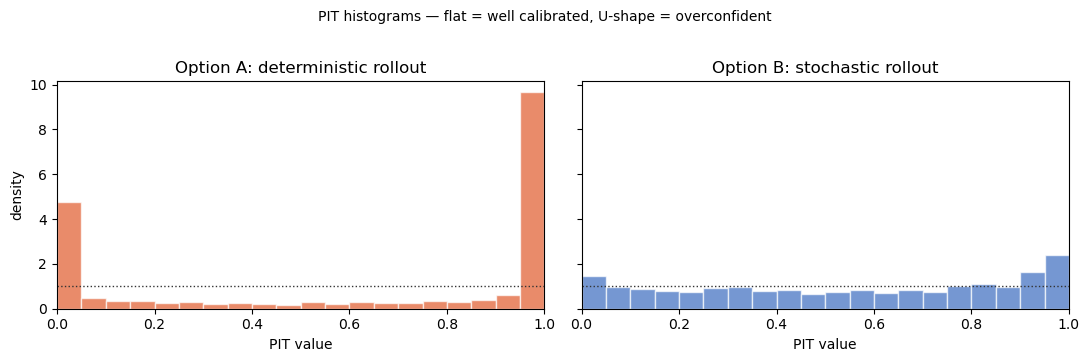

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)

axes[0].hist(pit_det, bins=20, density=True, color="#e05a2b", alpha=0.7, edgecolor="white")
axes[0].axhline(1.0, color="#333", ls=":", lw=1)
axes[0].set_xlabel("PIT value")
axes[0].set_ylabel("density")
axes[0].set_title("Option A: deterministic rollout")
axes[0].set_xlim(0, 1)

axes[1].hist(pit_values, bins=20, density=True, color="#3a6bbf", alpha=0.7, edgecolor="white")
axes[1].axhline(1.0, color="#333", ls=":", lw=1)
axes[1].set_xlabel("PIT value")
axes[1].set_title("Option B: stochastic rollout")
axes[1].set_xlim(0, 1)

plt.suptitle("PIT histograms — flat = well calibrated, U-shape = overconfident", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

The stochastic rollout (right) should be roughly flat — the truth lands uniformly across the ensemble. The deterministic rollout (left) typically shows a U-shape: the truth falls in the tails of the predicted distribution too often, because the bands are too narrow.

## 8. How many trajectories do you need?

More trajectories = more precise estimates, but more compute. Let's see how the **median** and the **90% band edges** stabilize as $M$ grows, for one example window.

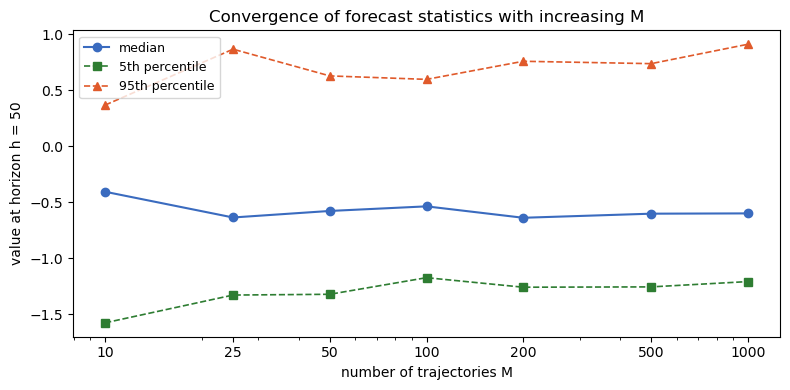

In [13]:
M_values = [10, 25, 50, 100, 200, 500, 1000]
ctx_demo = torch.from_numpy(x[start : start + CONTEXT].astype(np.float32))

# Run rollouts at different M and track quantiles at the last horizon step (h = HORIZON)
q05_by_M, q50_by_M, q95_by_M = [], [], []

for M_try in M_values:
    tr = stochastic_rollout(model, ctx_demo, HORIZON, M=M_try)
    vals = tr[:, -1]   # distribution at the last horizon step
    q05_by_M.append(np.percentile(vals, 5))
    q50_by_M.append(np.median(vals))
    q95_by_M.append(np.percentile(vals, 95))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(M_values, q50_by_M, "o-", color="#3a6bbf", lw=1.5, label="median")
ax.plot(M_values, q05_by_M, "s--", color="#2e7d32", lw=1.2, label="5th percentile")
ax.plot(M_values, q95_by_M, "^--", color="#e05a2b", lw=1.2, label="95th percentile")
ax.set_xscale("log")
ax.set_xlabel("number of trajectories M")
ax.set_ylabel(f"value at horizon h = {HORIZON}")
ax.legend(fontsize=9)
ax.set_title("Convergence of forecast statistics with increasing M")
ax.set_xticks(M_values)
ax.set_xticklabels(M_values)
plt.tight_layout()
plt.show()

The **median** (blue) stabilizes quickly — even $M = 25$ is decent. The **tail quantiles** (5th, 95th) need more samples because you're estimating the edges of the distribution, where individual draws have a big effect. For reliable 90% bands, $M = 200$ is a safe choice. For just a central forecast, $M = 50$ is often enough.

## 9. Practical notes

**Keep the clamp during rollout.** The model is feeding on its own predictions — inputs it never saw during training. Without the same $\log\sigma$ clamp used in training, a single unlucky trajectory can push $\sigma$ to zero or infinity and corrupt everything downstream:

```python
log_sigma = torch.clamp(log_sigma, min=-5.0, max=2.0)
```

This is already built into our model's `forward()` method.

**Batching is key.** The stochastic rollout function processes all $M$ trajectories as a single batch — one forward pass per horizon step, not $M$ separate passes. This is what makes it fast enough on CPU.

**The median, not the mean.** A few trajectories occasionally wander to extreme values. The median is robust to these outliers; the mean gets pulled by them.

**Multi-step heads are not a replacement.** Some architectures predict steps 2, 3, ... $H$ directly. These give *marginal* distributions at each step but not a *joint* distribution over the full future. Only the autoregressive stochastic rollout produces coherent trajectories where step $h$ depends on step $h{-}1$.

## Summary

- **Deterministic rollout** (feed $\mu$ back) underestimates uncertainty because it treats each intermediate prediction as certain. Coverage degrades with horizon.
- **Stochastic rollout** (sample and feed back, $M$ times) propagates uncertainty correctly through the autoregressive chain. Coverage stays honest.
- The difference is barely any extra code — just replace the line that appends $\mu$ with a line that appends a **sample** from $\mathcal{N}(\mu, \sigma^2)$, and run $M$ copies in parallel.
- **Coverage-horizon plots** and **PIT histograms** are the diagnostic tools: they tell you whether the forecast bands are honest at every horizon step.

**Next up:** the Gaussian assumption is still a simplification. Richer predictive distributions — quantized tokens, flow matching — are the subject of the next part of this series.